# How many make the list when two members tie?

**Week 2, Wednesday. Round 2 of 3: SQL window functions.** By the end of this notebook you can
say what ROW_NUMBER, RANK and DENSE_RANK do with a tie, count the rows each one ships at the line,
and write the tie rule down as a business decision with its count beside it.

> **The head of Retail-Plus asks.** "Ties matter. If two members spent the same, I want them ranked
> the same, and I want to know how many made the top fifty, not forty-nine because of a tie."

> **Kavya's review, at the end of this round.** "The tie rule is a business decision written as a
> function name. Pick RANK, and put how many it shipped in the same line as the list."

Round 1 built the protect list with `row_number()` inside each segment: 155 rows, 35 Business, 50
Retail-Core, 50 Retail-Plus and 20 Student, with `customer_id` quietly deciding any tie. This round
asks what that quiet choice did. The SQL behind every cell is
`sql/C2_W02_D03_02_protect_list_STUDENT.sql`.

**Setup.** The first lines find `scripts/c2kit.py` by walking up from this folder and import it as
`kit`; the helper opens the Kalpa warehouse with the settings the Codespace exports. `sql` runs a
query through `kit.sql` and hands back rows whose amounts are plain Python numbers, `show` prints a
query's rows as a table with rupees in Indian grouping, and `Q2_PER_MEMBER` is Monday's definition
of Q2 revenue per member, the booked amount of the member's Q2 orders of every status, written once
so every query below starts from the same number.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import decimal


def show(rows, money=(), caption="", limit=15):
    """Query rows as the kit's table, with every rupee column in Indian grouping."""
    def cell(h, v):
        if v is None:
            return ""
        return kit.rupees(v) if h in money else str(v)
    headers = list(rows[0])
    body = [[cell(h, r[h]) for h in headers] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..."] * len(headers))
    kit.table(headers, body, caption or f"{len(rows)} rows")


def crore(v):
    """A large rupee figure on a chart axis, in crore, so the tick labels stay short."""
    return f"Rs {v / 1e7:.2f} cr"


Q2_PER_MEMBER = """
    SELECT c.segment, o.customer_id, sum(o.amount) AS q2_revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment, o.customer_id"""

SEGMENTS = ["Business", "Retail-Core", "Retail-Plus", "Student"]

def sql(query):
    """kit.sql with Postgres numerics turned into Python numbers, so charts and arithmetic take them."""
    def num(v):
        if isinstance(v, decimal.Decimal):
            return int(v) if v == v.to_integral_value() else float(v)
        return v
    return [{k: num(v) for k, v in row.items()} for row in kit.sql(query)]


first = sql("SELECT count(*) AS orders, sum(amount) FILTER (WHERE quarter = 'Q2') AS q2 FROM orders")[0]
print(f"The warehouse answered: {first['orders']:,} orders, Q2 booked {kit.rupees(first['q2'])}.")

The warehouse answered: 1,000 orders, Q2 booked Rs 9,84,00,000.


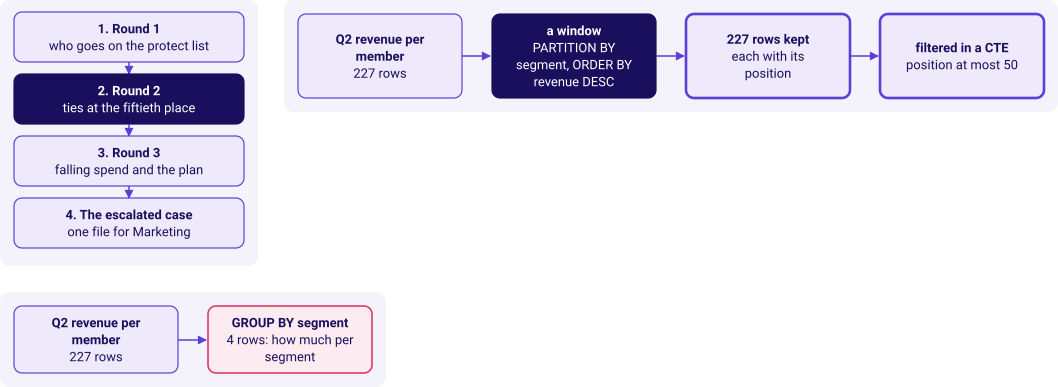

In [2]:
kit.side_by_side(
    kit.ladder(["Round 1\nwho goes on the protect list",
                "Round 2\nties at the fiftieth place",
                "Round 3\nfalling spend and the plan",
                "The escalated case\none file for Marketing"], lit=1, show=False),
    kit.flow(["Q2 revenue per member\n227 rows",
              "a window\nPARTITION BY segment, ORDER BY revenue DESC",
              "227 rows kept\neach with its position",
              "filtered in a CTE\nposition at most 50"],
             kinds=["plain", "lit", "known", "known"], show=False),
    kit.flow(["Q2 revenue per member\n227 rows",
              "GROUP BY segment\n4 rows: how much per segment"],
             kinds=["plain", "bad"], show=False),
)

## 1. Three functions, one tie: RANK gives 1, 1, 3

Six invented members, A to F, labelled invented because they exist only to show the mechanism on
one screen. A and B spent Rs 7,500 each and lead the list; D and E tie lower down on Rs 5,200.

**Predict before you run.** What does `rank()` give A, B and C? a) 1, 2, 3; b) 1, 1, 2;
c) 1, 1, 3; d) 1, 1, 1.

member,spend,row_number,rank,dense_rank
A,"Rs 7,500",1,1,1
B,"Rs 7,500",2,1,1
C,"Rs 6,000",3,3,2
D,"Rs 5,200",4,4,3
E,"Rs 5,200",5,4,3
F,"Rs 4,100",6,6,4


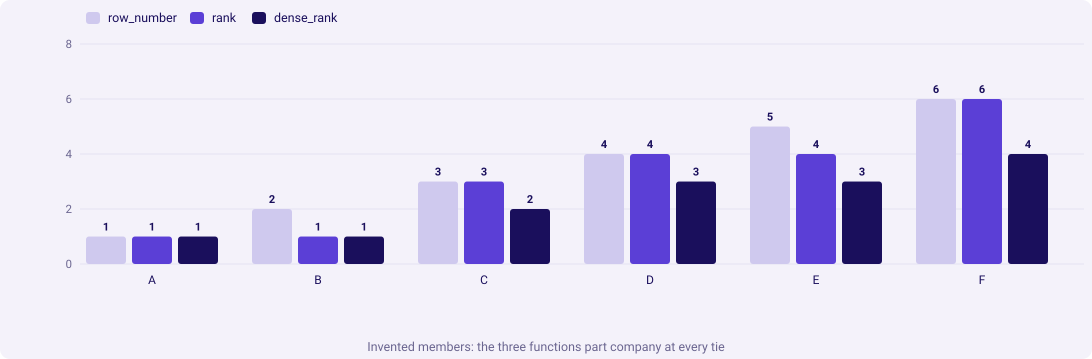

In [3]:
invented = sql("""
    WITH invented (member, spend) AS (
        VALUES ('A', 7500), ('B', 7500), ('C', 6000), ('D', 5200), ('E', 5200), ('F', 4100)
    )
    SELECT member, spend,
           row_number() OVER (ORDER BY spend DESC, member) AS row_number,
           rank()       OVER (ORDER BY spend DESC)         AS rank,
           dense_rank() OVER (ORDER BY spend DESC)         AS dense_rank
    FROM   invented
    ORDER  BY spend DESC, member""")
show(invented, money=("spend",), caption="Six invented members, three functions")
kit.columns([r["member"] for r in invented],
            [("row_number", [r["row_number"] for r in invented]),
             ("rank", [r["rank"] for r in invented]),
             ("dense_rank", [r["dense_rank"] for r in invented])],
            title="Invented members: the three functions part company at every tie")

**What happened.** The answer is c. RANK gives tied members the same position and then skips, so
after two members share 1 the next member is 3: the position still says how many members spent
more. DENSE_RANK shares the position without the gap, so C is 2 and F is 4. ROW_NUMBER never shares:
A and B get 1 and 2, and only the tiebreaker inside the window, here the member's letter, decides
which is which.

In [4]:
kit.check("ROW_NUMBER numbers 1 to 6 with no repeats", [r["row_number"] for r in invented] == [1, 2, 3, 4, 5, 6])
kit.check("RANK shares and skips: 1, 1, 3, 4, 4, 6", [r["rank"] for r in invented] == [1, 1, 3, 4, 4, 6])
kit.check("DENSE_RANK shares without a gap: 1, 1, 2, 3, 3, 4",
          [r["dense_rank"] for r in invented] == [1, 1, 2, 3, 3, 4])

## 2. The tie at the line: each rule ships a different number of rows

Invented again: Marketing wants a top four, and the fourth and fifth members both spent Rs 7,400.
`count(*) OVER (PARTITION BY spend)` carries the size of each member's tie, which gives a fourth
rule, "whole ties only": ship a tied group only if all of it fits.

**Predict before you run.** How many rows does `rank() <= 4` ship? a) 3; b) 4; c) 5; d) 6.

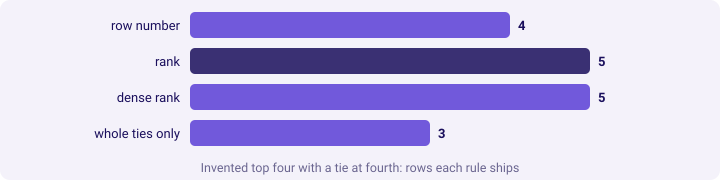

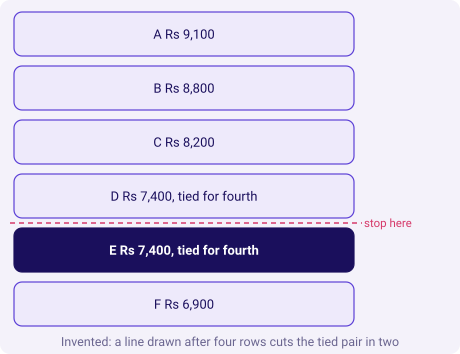

In [5]:
line = sql("""
    WITH invented (member, spend) AS (
        VALUES ('A', 9100), ('B', 8800), ('C', 8200), ('D', 7400), ('E', 7400), ('F', 6900)
    ),
    r AS (
        SELECT member, spend,
               row_number() OVER (ORDER BY spend DESC, member) AS rn,
               rank()       OVER (ORDER BY spend DESC)         AS rk,
               dense_rank() OVER (ORDER BY spend DESC)         AS dr,
               count(*)     OVER (PARTITION BY spend)          AS tied_with
        FROM   invented
    )
    SELECT count(*) FILTER (WHERE rn <= 4)                 AS row_number_ships,
           count(*) FILTER (WHERE rk <= 4)                 AS rank_ships,
           count(*) FILTER (WHERE dr <= 4)                 AS dense_rank_ships,
           count(*) FILTER (WHERE rk + tied_with - 1 <= 4) AS whole_ties_only_ships
    FROM   r""")[0]
kit.bars([(k.replace("_ships", "").replace("_", " "), v) for k, v in line.items()], lit=(1,),
         title="Invented top four with a tie at fourth: rows each rule ships")
kit.decision_ladder(["F Rs 6,900", "E Rs 7,400, tied for fourth", "D Rs 7,400, tied for fourth",
                     "C Rs 8,200", "B Rs 8,800", "A Rs 9,100"],
                    cut_at=1, title="Invented: a line drawn after four rows cuts the tied pair in two")

**What happened.** The answer is c. RANK ships five, because D and E share fourth place and both
belong on the list. DENSE_RANK also ships five here. ROW_NUMBER ships exactly four and drops E, for
no reason except that E sorts after D. "Whole ties only" ships three, dropping a member who spent
exactly what the fourth did, which is the forty-nine the head of Retail-Plus forbade.

In [6]:
kit.check("ROW_NUMBER ships exactly four", line["row_number_ships"] == 4)
kit.check("RANK ships five: the tied pair travels together", line["rank_ships"] == 5)
kit.check("whole ties only ships three", line["whole_ties_only_ships"] == 3)

## 3. The trap: DENSE_RANK sounds like "ties rank the same" and ships 52

**The plausible wrong answer.** An analyst hears "if two members spent the same, rank them the
same", reaches for the function whose name sounds closest, and writes `dense_rank() <= 50`. On the
invented top four it agreed with RANK, so it looks safe. Run it on Retail-Core, where there is no
tie at the fiftieth place at all.

**Predict before you run.** How many Retail-Core members does `dense_rank() <= 50` ship? a) 49;
b) 50; c) 51; d) 52.

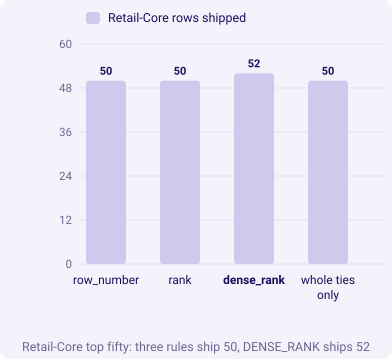

In [7]:
RULES = f"""
    WITH q2 AS ({Q2_PER_MEMBER}),
    r AS (
        SELECT segment, customer_id, q2_revenue,
               row_number() OVER (PARTITION BY segment ORDER BY q2_revenue DESC, customer_id) AS rn,
               rank()       OVER (PARTITION BY segment ORDER BY q2_revenue DESC)              AS rk,
               dense_rank() OVER (PARTITION BY segment ORDER BY q2_revenue DESC)              AS dr,
               count(*)     OVER (PARTITION BY segment, q2_revenue)                           AS tied_with
        FROM   q2
    )"""
core = sql(RULES + """
    SELECT count(*) FILTER (WHERE rn <= 50)                 AS row_number_ships,
           count(*) FILTER (WHERE rk <= 50)                 AS rank_ships,
           count(*) FILTER (WHERE dr <= 50)                 AS dense_rank_ships,
           count(*) FILTER (WHERE rk + tied_with - 1 <= 50) AS whole_ties_only_ships
    FROM   r
    WHERE  segment = 'Retail-Core'""")[0]
kit.columns(["row_number", "rank", "dense_rank", "whole ties only"],
            [("Retail-Core rows shipped", list(core.values()))],
            title="Retail-Core top fifty: three rules ship 50, DENSE_RANK ships 52", lit=(2,))

**What happened.** The answer is d, 52.

**Why it is wrong.** DENSE_RANK closes the gaps a tie leaves, so every tie higher up the list pulls
the members below it one place up. By the fiftieth dense position Retail-Core has run through 52
members, and two members who ranked 51st and 52nd by spend are on a list Marketing will act on. The
report says "top fifty" and ships 52, and nobody at the line tied. The check that exposes it is to
read positions 44 to 54 with all three functions side by side.

rn,rk,dr,customer_id,q2_revenue
44,44,42,C-0003,"Rs 3,440"
45,45,43,C-0004,"Rs 3,120"
46,46,44,C-0007,"Rs 3,100"
47,47,45,C-0127,"Rs 3,030"
48,48,46,C-0054,"Rs 3,000"
49,49,47,C-0072,"Rs 2,990"
50,50,48,C-0005,"Rs 2,980"
51,51,49,C-0092,"Rs 2,950"
52,52,50,C-0094,"Rs 2,910"
53,53,51,C-0048,"Rs 2,870"


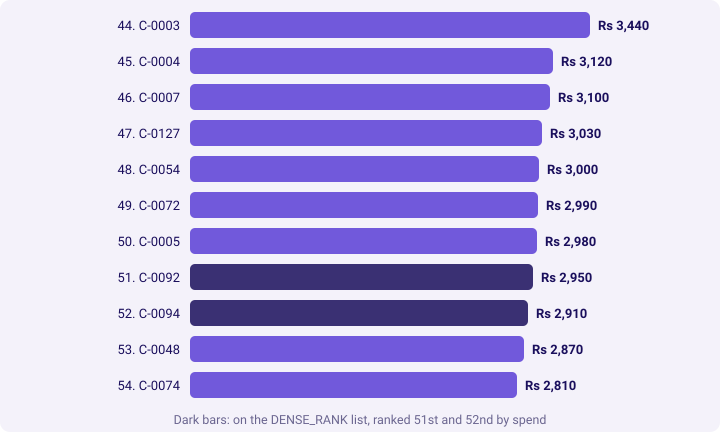

In [8]:
edge = sql(RULES + """
    SELECT rn, rk, dr, customer_id, q2_revenue
    FROM   r
    WHERE  segment = 'Retail-Core' AND rn BETWEEN 44 AND 54
    ORDER  BY rn""")
show(edge, money=("q2_revenue",), caption="Retail-Core, positions 44 to 54, all three functions")
extra = [r for r in edge if r["dr"] <= 50 and r["rk"] > 50]
kit.bars([(f'{r["rn"]}. {r["customer_id"]}', r["q2_revenue"]) for r in edge], fmt=kit.rupees,
         lit=[i for i, r in enumerate(edge) if r in extra],
         title="Dark bars: on the DENSE_RANK list, ranked 51st and 52nd by spend")
kit.check("DENSE_RANK ships 52 in Retail-Core", core["dense_rank_ships"] == 52)
kit.check("the two extra members rank 51 and 52 by RANK", [r["rk"] for r in extra] == [51, 52],
          ", ".join(r["customer_id"] for r in extra))
kit.check("ROW_NUMBER and RANK agree on 50: no tie sits at the line", core["row_number_ships"] == core["rank_ships"] == 50)

**The fix.** RANK inside each segment. In Retail-Core it takes the list from 52 rows back to 50,
removing the two members at 51st and 52nd, Rs 2,950 and Rs 2,910, Rs 5,860 of Q2 revenue that was
never in the top fifty.

## 4. The rule written down: RANK inside each segment, and the count said out loud

RANK does both things the head of Retail-Plus asked for: tied members share a position, and every
member at or above fiftieth ships, so nobody at the line is dropped by a coin toss. The rule costs
one sentence in the report, the number of members shipped per segment and why.

**Predict before you run.** How many Business and Student members does `rank() <= 50` ship?
a) fifty each; b) every Q2 buyer, 35 and 20; c) fewer than their buyers, since ties shrink a list;
d) it cannot be said until the ties are known.

segment,members_on_the_list,last_position,q2_buyers
Business,35,35,35
Retail-Core,50,50,96
Student,20,20,20


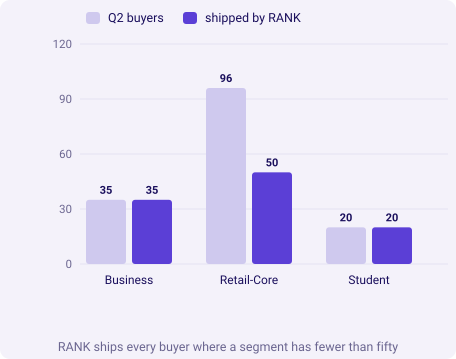

In [9]:
rule = sql(RULES + """
    SELECT segment,
           count(*) FILTER (WHERE rk <= 50) AS members_on_the_list,
           max(rk) FILTER (WHERE rk <= 50)  AS last_position,
           count(*)                         AS q2_buyers
    FROM   r
    WHERE  segment <> 'Retail-Plus'
    GROUP  BY segment
    ORDER  BY segment""")
shipped = {r["segment"]: r["members_on_the_list"] for r in rule}
show(rule, caption="RANK within each segment, three segments shown; Retail-Plus is your turn below")
kit.columns([r["segment"] for r in rule],
            [("Q2 buyers", [r["q2_buyers"] for r in rule]),
             ("shipped by RANK", [r["members_on_the_list"] for r in rule])],
            title="RANK ships every buyer where a segment has fewer than fifty")

**What happened.** The answer is b. Business and Student ship all 35 and 20 buyers, and Retail-Core
ships 50 with its last position at 50, because no Retail-Core tie sits on the line.

**ROW_NUMBER's coin toss.** Without a tiebreaker, `row_number() OVER (ORDER BY spend DESC)` numbers
tied rows in whatever order the database reads them, so a member can be fiftieth on Monday's run and
fifty-first on Tuesday's with the same spend. Adding `customer_id` to the window's ORDER BY makes the
toss repeatable, and it is still a toss: the member with the smaller id wins, which is no reason a
business would give. The cell below shows it on the invented pair, fed to the database in two
different row orders.

In [10]:
def winner(values_sql, tiebreak):
    order = "spend DESC, member" if tiebreak else "spend DESC"
    return sql(f"""
        WITH invented (member, spend) AS (VALUES {values_sql})
        SELECT member FROM (SELECT member, row_number() OVER (ORDER BY {order}) AS rn FROM invented) x
        WHERE rn = 1""")[0]["member"]

orders_in = {"A then B": "('A', 7500), ('B', 7500), ('C', 6000)",
             "B then A": "('B', 7500), ('A', 7500), ('C', 6000)"}
kit.table(["rows fed in", "first place, no tiebreaker", "first place, member as tiebreaker"],
          [(k, winner(v, False), winner(v, True)) for k, v in orders_in.items()],
          caption="Invented: with a tiebreaker the winner never depends on how the rows arrived")
kit.check("with a tiebreaker both feeds give the same first place",
          len({winner(v, True) for v in orders_in.values()}) == 1)
kit.check("RANK ships every Business and Student buyer", shipped["Business"] == 35 and shipped["Student"] == 20)
kit.check("RANK ships 50 in Retail-Core", shipped["Retail-Core"] == 50)

rows fed in,"first place, no tiebreaker","first place, member as tiebreaker"
A then B,A,A
B then A,B,A


**Your turn.** Retail-Plus is the segment whose head asked the question, so run the same count on
it yourself. Type these lines into the empty cell below and run them, then write the one sentence
the report carries: the rule, the count, and why.

```python
rp = sql(RULES + """
    SELECT count(*) FILTER (WHERE rn <= 50)                 AS row_number_ships,
           count(*) FILTER (WHERE rk <= 50)                 AS rank_ships,
           count(*) FILTER (WHERE dr <= 50)                 AS dense_rank_ships,
           count(*) FILTER (WHERE rk + tied_with - 1 <= 50) AS whole_ties_only_ships
    FROM   r WHERE segment = 'Retail-Plus'""")
show(rp)
show(sql(RULES + """
    SELECT rn, rk, dr, customer_id, q2_revenue FROM r
    WHERE  segment = 'Retail-Plus' AND rn BETWEEN 44 AND 54 ORDER BY rn"""), money=("q2_revenue",))
```

The sentence has this shape: "We ranked with RANK inside each segment, so tied members share a
place: the Retail-Plus list carries N members, because ..."

## What this round established

> **Kavya's review.** "The tie rule is a business decision written as a function name. Pick RANK,
> and put how many it shipped in the same line as the list. A list that says fifty and ships
> fifty-two will be found by the first person who counts it."

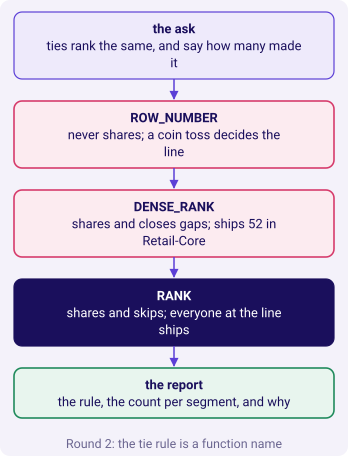

Rule,What it does with a tie,Retail-Core ships
row_number,Never shares a position; the tiebreaker decides who is in.,50
rank,Shares the position and leaves a gap after it.,50
dense_rank,"Shares the position and closes the gap, so later members move up.",52
whole ties only,Drops a tied group that does not fit whole.,50


In [11]:
kit.vflow(["the ask\nties rank the same, and say how many made it",
           "ROW_NUMBER\nnever shares; a coin toss decides the line",
           "DENSE_RANK\nshares and closes gaps; ships 52 in Retail-Core",
           "RANK\nshares and skips; everyone at the line ships",
           "the report\nthe rule, the count per segment, and why"],
          kinds=["plain", "bad", "bad", "lit", "good"],
          title="Round 2: the tie rule is a function name")
kit.table(["Rule", "What it does with a tie", "Retail-Core ships"],
          [("row_number", "Never shares a position; the tiebreaker decides who is in.", core["row_number_ships"]),
           ("rank", "Shares the position and leaves a gap after it.", core["rank_ships"]),
           ("dense_rank", "Shares the position and closes the gap, so later members move up.", core["dense_rank_ships"]),
           ("whole ties only", "Drops a tied group that does not fit whole.", core["whole_ties_only_ships"])],
          caption="What Round 2 established")

### In the interview

**[S] RANK, DENSE_RANK and ROW_NUMBER on a tie.** "Take two members tied on the top spend. ROW_NUMBER
gives them 1 and 2 and the third member 3; which of the pair gets 1 depends on the tiebreaker in the
window's ORDER BY, or on nothing at all if there is none. RANK gives both 1 and the third member 3,
so a position still says how many rows came before it. DENSE_RANK gives both 1 and the third member
2, so there are no gaps and the positions stop counting rows. On the invented list A to F that is
1, 1, 3 for RANK and 1, 1, 2 for DENSE_RANK."

**[D] The business says 'ties rank the same'; which function, and how many rows might the top-N
report ship?** "RANK, filtered at position N or better. It ships at least N rows whenever the group
has N members, and more than N when a tie straddles the line, one extra row for each extra member
of that tie. I would not use DENSE_RANK, because it ships more than N rows even with no tie at the
line: every tie above the line pulls the later members up, which is how Retail-Core's top fifty
became 52. The report then states the count and the reason in one line."

**[F] Your top-fifty list came back with 51 rows. What do you tell the stakeholder, and is it a
bug?** "First I find out whether it is a tie or a mistake: I count members at the last position and
read the rows either side of the line with ROW_NUMBER, RANK and DENSE_RANK side by side. If two
members share fiftieth on exactly the same spend and I ranked with RANK, it is the rule working, and
I tell the stakeholder that the list has 51 members because two tie at fiftieth, with both names.
If the extra row came from DENSE_RANK, or from a join that duplicated a member, it is a bug, and I
fix it before the list goes anywhere."

### Depth: the rules a business might ask for, and the one column that serves them all

Every tie rule in this round can be written from two numbers per member, the RANK position and the
size of the member's tie, `count(*) OVER (PARTITION BY segment, q2_revenue)`. A member is in the
RANK list when the position is at most fifty; in the "whole ties only" list when the position plus
the tie size minus one is at most fifty; and at the line exactly when the position is at most fifty
and the position plus the tie size minus one is past it. That last test finds every tie that
straddles a line, in any segment, without reading a single name, which is the first query to run
when a count comes back one above what was asked for.

segment,members_in_a_tie_across_the_line
Business,0
Retail-Core,0
Student,0


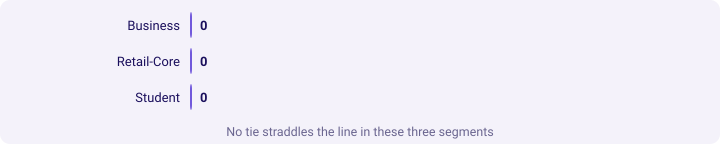

In [12]:
straddle = sql(RULES + """
    SELECT segment, count(*) FILTER (WHERE rk <= 50 AND rk + tied_with - 1 > 50) AS members_in_a_tie_across_the_line
    FROM   r
    WHERE  segment <> 'Retail-Plus'
    GROUP  BY segment
    ORDER  BY segment""")
show(straddle, caption="Ties that straddle the fiftieth place, three segments")
kit.bars([(r["segment"], r["members_in_a_tie_across_the_line"]) for r in straddle],
         title="No tie straddles the line in these three segments")
kit.check("no tie crosses the line in Business, Retail-Core or Student",
          sum(r["members_in_a_tie_across_the_line"] for r in straddle) == 0)

In [13]:
kit.check_summary()
print("Next: Round 3 asks whose monthly spend is falling, and whether the quarter is on plan.")

Next: Round 3 asks whose monthly spend is falling, and whether the quarter is on plan.
